### Test/Train Split and Encoding

In [51]:
# Import packages
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from tabulate import tabulate
import miceforest as mf

In [2]:
# Written by Elizabeth Greenan

In [3]:
# Read in cleaned_data.csv
e_cigarette_data = pd.read_csv("../data/cleaned_data.csv")
e_cigarette_data.head()

,Unnamed: 0,BMI,Number_of_Children,Dentist_Visit_Last_Year,Health_Insurance,Lung_Cancer_Suspected_Risk,Marijuana_Use_30_Days,Medical_Visit_Missed_Due_to_Cost,Number_of_Days_Last_Month_Poor_Health,High_Financial_Stress_Burden,...,Health_Rating,Annual_Income,Days_Poor_Physical_Health,Education,Social_Emotional_Support,General_Health_Personal_Rating,Life_Satisfaction,Marital_Status,Sugar_Soda_Drinks_Per_Day,Non_Soda_Sugar_Drinks_Per_Day
0,0,22.49,0.0,1.0,1.0,NaN,NaN,0.0,0.0,0.0,...,Good_or_Better_Health,Unknown,1-13_Days,Grade_12_or_GED_(high_school_graduate,Always,Good,Very_satisfied,Widowed,NaN,NaN
1,1,25.83,0.0,1.0,1.0,NaN,NaN,0.0,NaN,0.0,...,Good_or_Better_Health,"$200,000+",0_Days,College_4_years_or_more_(college_graduate),Always,Excellent,Very_satisfied,Married,NaN,NaN
2,2,22.53,0.0,0.0,1.0,NaN,NaN,1.0,1.0,0.0,...,Good_or_Better_Health,Unknown,14+_Days,College_1-3_years_(some_college_or_technical_s...,Usually,Very_good,Very_satisfied,Member_of_unmarried_couple,NaN,NaN
3,3,25.09,0.0,1.0,1.0,NaN,NaN,0.0,NaN,0.0,...,Good_or_Better_Health,"Less_than_$50,000",0_Days,College_4_years_or_more_(college_graduate),Always,Excellent,Very_satisfied,Married,NaN,NaN
4,4,19.77,0.0,1.0,1.0,0.0,NaN,0.0,NaN,0.0,...,Good_or_Better_Health,"Less_than_$20,000",0_Days,College_1-3_years_(some_college_or_technical_s...,Rarely,Good,Satisfied,Never_Married,NaN,NaN


In [4]:
# # Check if target variable has any missing values
e_cols_with_na = e_cigarette_data.columns[e_cigarette_data.isna().any()].tolist()

print(e_cols_with_na)

['BMI', 'Number_of_Children', 'Dentist_Visit_Last_Year', 'Health_Insurance', 'Lung_Cancer_Suspected_Risk', 'Marijuana_Use_30_Days', 'Medical_Visit_Missed_Due_to_Cost', 'Number_of_Days_Last_Month_Poor_Health', 'High_Financial_Stress_Burden', 'Has_Disability', 'Diabetic_History', 'E_Cig_User', 'Total_Drinks_30_days', 'Exercise_Outside_Work_Past_Month', 'Sugar_Soda_Drinks_Per_Day', 'Non_Soda_Sugar_Drinks_Per_Day']


In [5]:
# Removing target variable missing values
e_cigarette_data = e_cigarette_data.dropna(subset=['E_Cig_User'])

In [6]:
# Checking to make sure it was removed
e_cigarette_data['E_Cig_User'].isnull().any()

False

In [7]:
# Remove the Unnamed: 0 field
e_cigarette_data = e_cigarette_data.drop(columns=['Unnamed: 0'])
e_cigarette_data.head()

,BMI,Number_of_Children,Dentist_Visit_Last_Year,Health_Insurance,Lung_Cancer_Suspected_Risk,Marijuana_Use_30_Days,Medical_Visit_Missed_Due_to_Cost,Number_of_Days_Last_Month_Poor_Health,High_Financial_Stress_Burden,Sex,...,Health_Rating,Annual_Income,Days_Poor_Physical_Health,Education,Social_Emotional_Support,General_Health_Personal_Rating,Life_Satisfaction,Marital_Status,Sugar_Soda_Drinks_Per_Day,Non_Soda_Sugar_Drinks_Per_Day
0,22.49,0.0,1.0,1.0,NaN,NaN,0.0,0.0,0.0,Female,...,Good_or_Better_Health,Unknown,1-13_Days,Grade_12_or_GED_(high_school_graduate,Always,Good,Very_satisfied,Widowed,NaN,NaN
1,25.83,0.0,1.0,1.0,NaN,NaN,0.0,NaN,0.0,Male,...,Good_or_Better_Health,"$200,000+",0_Days,College_4_years_or_more_(college_graduate),Always,Excellent,Very_satisfied,Married,NaN,NaN
2,22.53,0.0,0.0,1.0,NaN,NaN,1.0,1.0,0.0,Male,...,Good_or_Better_Health,Unknown,14+_Days,College_1-3_years_(some_college_or_technical_s...,Usually,Very_good,Very_satisfied,Member_of_unmarried_couple,NaN,NaN
3,25.09,0.0,1.0,1.0,NaN,NaN,0.0,NaN,0.0,Male,...,Good_or_Better_Health,"Less_than_$50,000",0_Days,College_4_years_or_more_(college_graduate),Always,Excellent,Very_satisfied,Married,NaN,NaN
4,19.77,0.0,1.0,1.0,0.0,NaN,0.0,NaN,0.0,Male,...,Good_or_Better_Health,"Less_than_$20,000",0_Days,College_1-3_years_(some_college_or_technical_s...,Rarely,Good,Satisfied,Never_Married,NaN,NaN


In [8]:
# Check dimensions
e_cigarette_data.shape

(424919, 31)

In [9]:
# Check columns
print(e_cigarette_data.columns)

Index(['BMI', 'Number_of_Children', 'Dentist_Visit_Last_Year',
       'Health_Insurance', 'Lung_Cancer_Suspected_Risk',
       'Marijuana_Use_30_Days', 'Medical_Visit_Missed_Due_to_Cost',
       'Number_of_Days_Last_Month_Poor_Health', 'High_Financial_Stress_Burden',
       'Sex', 'Has_Disability', 'Diabetic_History', 'Days_Poor_Mental_Health',
       'Age_Category', 'E_Cig_User', 'Other_Tobacco_Usage', 'Race',
       'Total_Drinks_30_days', 'Time_Since_Last_Check_Up',
       'Exercise_Outside_Work_Past_Month', 'Loneliness', 'Health_Rating',
       'Annual_Income', 'Days_Poor_Physical_Health', 'Education',
       'Social_Emotional_Support', 'General_Health_Personal_Rating',
       'Life_Satisfaction', 'Marital_Status', 'Sugar_Soda_Drinks_Per_Day',
       'Non_Soda_Sugar_Drinks_Per_Day'],
      dtype='object')


In [10]:
# Move the target/response variable (E_Cig_User) to the end of the dataframe
# Source: https://stackoverflow.com/questions/72782872/move-a-dataframe-column-to-last-column
e_cigarette_data['E_Cig_User'] = e_cigarette_data.pop('E_Cig_User')

In [11]:
# Make sure E_Cig_User is last variable
print(e_cigarette_data.columns)

Index(['BMI', 'Number_of_Children', 'Dentist_Visit_Last_Year',
       'Health_Insurance', 'Lung_Cancer_Suspected_Risk',
       'Marijuana_Use_30_Days', 'Medical_Visit_Missed_Due_to_Cost',
       'Number_of_Days_Last_Month_Poor_Health', 'High_Financial_Stress_Burden',
       'Sex', 'Has_Disability', 'Diabetic_History', 'Days_Poor_Mental_Health',
       'Age_Category', 'Other_Tobacco_Usage', 'Race', 'Total_Drinks_30_days',
       'Time_Since_Last_Check_Up', 'Exercise_Outside_Work_Past_Month',
       'Loneliness', 'Health_Rating', 'Annual_Income',
       'Days_Poor_Physical_Health', 'Education', 'Social_Emotional_Support',
       'General_Health_Personal_Rating', 'Life_Satisfaction', 'Marital_Status',
       'Sugar_Soda_Drinks_Per_Day', 'Non_Soda_Sugar_Drinks_Per_Day',
       'E_Cig_User'],
      dtype='object')


In [12]:
# Check dimensions
e_cigarette_data.shape

(424919, 31)

In [13]:
# Test/Train Split source: Used code Professor Geist provided (calcSplitRatio.py)

In [14]:
# p represents the number of parameters
def calcSplitRatio(e_cigarette_data, p = None):
    if p is None:
        p = e_cigarette_data.shape[1] - 1 # This assumes the last column is the target variable

    # Calculate the ideal number for the testing set
    test_N = (1 / np.sqrt(p)) * len(e_cigarette_data)

    # Calculate the testing proportion
    test_prop = round(test_N / len(e_cigarette_data), 2)

    # Calculate the training proportion
    train_prop = 1 - test_prop

    # Print the results
    print(f"The ideal split ratio is {train_prop}:{test_prop} training:testing")

    # Return the size of the training set proportion
    return train_prop

In [15]:
train_prop = calcSplitRatio(e_cigarette_data)

The ideal split ratio is 0.8200000000000001:0.18 training:testing


In [16]:
# The training proportion is 82% and the testing proportion is 18%.

## Supervised Test/Train Split

In [17]:
# Code written by Elizabeth Greenan
# Code source: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
# Referenced code from previous course (DSE6211: Lab 2)

# Remove the response variable
x = e_cigarette_data.drop('E_Cig_User', axis = 1)
# We want to predict the response variable
y = e_cigarette_data['E_Cig_User']
# Perform test/train split
# Random_state added to ensure reproducibility
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = train_prop, random_state = 1)

## Unsupervised Test/Train Split

In [18]:
# Code written by Elizabeth Greenan
# Since unsupervised does not use a response variable, the y code was removed
# Remove the response variable
x = e_cigarette_data.drop('E_Cig_User', axis = 1)
# Perform test/train split
# Random_state ensures reproducibility
x_train_unsupervised, x_test_unsupervised = train_test_split(x, train_size = train_prop, random_state = 1)

## Check results of split to ensure they are correct

In [19]:
print(x_train.shape)
print(x_test.shape)

(348433, 30)
(76486, 30)


In [20]:
print(y_train.shape)
print(y_test.shape)

(348433,)
(76486,)


In [21]:
# Confirm that the training set is approximately 82% and the test set is approximately 18%
training_ratio = len(x_train) / (len(x_train) + len(x_test))
test_ratio = len(x_test) / len(x)

print("Training ratio:", training_ratio)
print("Test ratio:", test_ratio)

Training ratio: 0.8199986350339712
Test ratio: 0.1800013649660288


In [22]:
# Confirm there is one less column, due to the removal of the response variable (should be 30)
x_train.head()

,BMI,Number_of_Children,Dentist_Visit_Last_Year,Health_Insurance,Lung_Cancer_Suspected_Risk,Marijuana_Use_30_Days,Medical_Visit_Missed_Due_to_Cost,Number_of_Days_Last_Month_Poor_Health,High_Financial_Stress_Burden,Sex,...,Health_Rating,Annual_Income,Days_Poor_Physical_Health,Education,Social_Emotional_Support,General_Health_Personal_Rating,Life_Satisfaction,Marital_Status,Sugar_Soda_Drinks_Per_Day,Non_Soda_Sugar_Drinks_Per_Day
294665,23.73,1.0,1.0,1.0,NaN,NaN,0.0,0.0,NaN,Male,...,Good_or_Better_Health,"Less_than_$200,000",0_Days,College_4_years_or_more_(college_graduate),Unknown,Excellent,Unknown,Married,NaN,NaN
304948,20.50,0.0,1.0,1.0,1.0,NaN,0.0,NaN,0.0,Female,...,Good_or_Better_Health,"Less_than_$200,000",0_Days,College_4_years_or_more_(college_graduate),Always,Very_good,Very_satisfied,Married,1.0,1.0
171185,27.94,0.0,0.0,1.0,NaN,NaN,0.0,5.0,NaN,Male,...,Fair_or_Poor_Health,Unknown,1-13_Days,Grades_1-8_(elementary),Unknown,Fair,Unknown,Widowed,NaN,NaN
99327,33.77,0.0,1.0,1.0,0.0,0.0,0.0,7.0,NaN,Male,...,Good_or_Better_Health,"Less_than_$150,000",1-13_Days,College_4_years_or_more_(college_graduate),Unknown,Good,Unknown,Married,NaN,NaN
21252,37.66,0.0,0.0,1.0,0.0,NaN,1.0,25.0,1.0,Male,...,Fair_or_Poor_Health,"Less_than_$15,000",14+_Days,College_1-3_years_(some_college_or_technical_s...,Rarely,Poor,Dissatisfied,Member_of_unmarried_couple,NaN,NaN


## MICE Imputation

In [23]:
# Written by Kevin Wilson
# Tested by Elizabeth Greenan

In [24]:
x_train.dtypes

BMI                                      float64
Number_of_Children                       float64
Dentist_Visit_Last_Year                  float64
Health_Insurance                         float64
Lung_Cancer_Suspected_Risk               float64
Marijuana_Use_30_Days                    float64
Medical_Visit_Missed_Due_to_Cost         float64
Number_of_Days_Last_Month_Poor_Health    float64
High_Financial_Stress_Burden             float64
Sex                                       object
Has_Disability                           float64
Diabetic_History                         float64
Days_Poor_Mental_Health                   object
Age_Category                              object
Other_Tobacco_Usage                       object
Race                                      object
Total_Drinks_30_days                     float64
Time_Since_Last_Check_Up                  object
Exercise_Outside_Work_Past_Month         float64
Loneliness                                object
Health_Rating       

In [25]:
x_train[['Sex', 'Days_Poor_Mental_Health', 'Age_Category', 'Other_Tobacco_Usage', 'Race', 'Time_Since_Last_Check_Up', 'Loneliness', 'Health_Rating', 'Annual_Income', 'Days_Poor_Physical_Health', 'Education', 'Social_Emotional_Support', 'General_Health_Personal_Rating', 'Life_Satisfaction', 'Marital_Status']] = x_train[['Sex', 'Days_Poor_Mental_Health', 'Age_Category', 'Other_Tobacco_Usage', 'Race', 'Time_Since_Last_Check_Up', 'Loneliness', 'Health_Rating', 'Annual_Income', 'Days_Poor_Physical_Health', 'Education', 'Social_Emotional_Support', 'General_Health_Personal_Rating', 'Life_Satisfaction', 'Marital_Status']].astype('category')

x_train = x_train.reset_index(drop=True)

# Create kernel
kernel = mf.ImputationKernel(x_train, num_datasets=4)

# Run MICE
kernel.mice(3)

# Return completed data
x_train_imputed = kernel.complete_data()

In [26]:
x_test[['Sex', 'Days_Poor_Mental_Health', 'Age_Category', 'Other_Tobacco_Usage', 'Race', 
        'Time_Since_Last_Check_Up', 'Loneliness', 'Health_Rating', 'Annual_Income', 
        'Days_Poor_Physical_Health', 'Education', 'Social_Emotional_Support', 
        'General_Health_Personal_Rating', 'Life_Satisfaction', 'Marital_Status']] = (
    x_test[['Sex', 'Days_Poor_Mental_Health', 'Age_Category', 'Other_Tobacco_Usage', 'Race', 
            'Time_Since_Last_Check_Up', 'Loneliness', 'Health_Rating', 'Annual_Income', 
            'Days_Poor_Physical_Health', 'Education', 'Social_Emotional_Support', 
            'General_Health_Personal_Rating', 'Life_Satisfaction', 'Marital_Status']]
    .astype('category')
)

x_test = x_test.reset_index(drop=True)

# Use the trained kernel to impute the test set
test_kernel = kernel.impute_new_data(x_test)

# Return completed test data
x_test_imputed = test_kernel.complete_data()

In [27]:
# Checking that MICE worked

In [28]:
x_train_check = x_train_imputed.columns[x_train_imputed.isna().any()].tolist()
print(x_train_check)

[]


In [29]:
x_test_check = x_test_imputed.columns[x_test_imputed.isna().any()].tolist()
print(x_test_check)

[]


## Checking Distribution After MICE

In [32]:
# Code written by Kevin Wilson
# Tested by Elizabeth Greenan

continuous_var = ['BMI', 'Number_of_Children', 'Marijuana_Use_30_Days', 'Number_of_Days_Last_Month_Poor_Health', 'Total_Drinks_30_days', 'Sugar_Soda_Drinks_Per_Day', 'Non_Soda_Sugar_Drinks_Per_Day']

In [33]:
# Create an empty list
combined_continuous_tables = []

# Create summary table that includes statistics
for col in continuous_var:
    series = x_test_imputed[col].dropna() # Drop NA values for continuous variable statistics
    n = series.count()
    mean = series.mean()
    std = series.std()
    median = series.median()
    se = std / np.sqrt(n)
    ci_lower = mean - 1.96 * se
    ci_upper = mean + 1.96 * se
    min_value = series.min()
    max_value = series.max()
    skew = series.skew()
    kurtosis = series.kurtosis()
    
    table = pd.DataFrame({'Variable': col,
                          'Count': [n],
                          'Mean': [mean],
                          'St. Dev.': [std],
                          'Median': [median],
                          '95% CI Lower': [ci_lower],
                          '95% CI Upper': [ci_upper],
                          'Min': [min_value],
                          'Max': [max_value],
                          'Skew': [skew],
                          'Kurtosis': [kurtosis]})
    combined_continuous_tables.append(table)

# Combine individual tables
final_continuous_table = pd.concat(combined_continuous_tables, ignore_index = True)

# Round numeric values
final_continuous_table = final_continuous_table.round({
    'Mean': 2,
    'St. Dev.': 2,
    'Median': 2,
    '95% CI Lower': 2,
    '95% CI Upper': 2,
    'Min': 2,
    'Max': 2,
    'Skew': 2,
    'Kurtosis': 2})

# Add commas to the count field
final_continuous_table['Count'] = final_continuous_table['Count'].map("{:,d}".format)

print(tabulate(final_continuous_table, headers = 'keys', tablefmt = 'fancy_grid', showindex = False))

╒═══════════════════════════════════════╤═════════╤════════╤════════════╤══════════╤════════════════╤════════════════╤═══════╤═════════╤════════╤════════════╕
│ Variable                              │   Count │   Mean │   St. Dev. │   Median │   95% CI Lower │   95% CI Upper │   Min │     Max │   Skew │   Kurtosis │
╞═══════════════════════════════════════╪═════════╪════════╪════════════╪══════════╪════════════════╪════════════════╪═══════╪═════════╪════════╪════════════╡
│ BMI                                   │  76,486 │  28.57 │       6.55 │    27.44 │          28.53 │          28.62 │ 12.08 │   76.82 │   1.28 │       3.27 │
├───────────────────────────────────────┼─────────┼────────┼────────────┼──────────┼────────────────┼────────────────┼───────┼─────────┼────────┼────────────┤
│ Number_of_Children                    │  76,486 │   0.48 │       1.1  │     0    │           0.47 │           0.48 │  0    │   82    │  14.35 │     846.35 │
├───────────────────────────────────────┼─────

In [34]:
# Create an empty list
continuous_var_by_outcome_class = []

for col in continuous_var:
    for outcome_class, group in e_cigarette_data.groupby('E_Cig_User', dropna = False): # E_Cig_User is the outcome class
        series = group[col].dropna() # Drop NA values for continuous variable statistics
        n = series.count()
        mean = series.mean()
        std = series.std()
        median = series.median()
        se = std / np.sqrt(n)
        ci_lower = mean - 1.96 * se
        ci_upper = mean + 1.96 * se
        min_value = series.min()
        max_value = series.max()
        skew = series.skew()
        kurtosis = series.kurtosis()
    
        table = pd.DataFrame({'Variable': col,
                              'Outcome Class': outcome_class,
                              'Count': [n],
                              'Mean': [mean],
                              'St. Dev.': [std],
                              'Median': [median],
                              '95% CI Lower': [ci_lower],
                              '95% CI Upper': [ci_upper],
                              'Min': [min_value],
                              'Max': [max_value],
                              'Skew': [skew],
                              'Kurtosis': [kurtosis]})

        continuous_var_by_outcome_class.append(table)

# Combine individual tables
continuous_table_by_outcome = pd.concat(continuous_var_by_outcome_class, ignore_index = True)

# Round numeric values
continuous_table_by_outcome = continuous_table_by_outcome.round({
    'Mean': 2,
    'St. Dev.': 2,
    'Median': 2,
    '95% CI Lower': 2,
    '95% CI Upper': 2,
    'Min': 2,
    'Max': 2,
    'Skew': 2,
    'Kurtosis': 2})

# Add commas to the count field
continuous_table_by_outcome['Count'] = continuous_table_by_outcome['Count'].map("{:,d}".format)

print(tabulate(continuous_table_by_outcome, headers = 'keys', tablefmt = 'fancy_grid', showindex = False))

╒═══════════════════════════════════════╤═════════════════╤═════════╤════════╤════════════╤══════════╤════════════════╤════════════════╤═══════╤═════════╤════════╤════════════╕
│ Variable                              │   Outcome Class │   Count │   Mean │   St. Dev. │   Median │   95% CI Lower │   95% CI Upper │   Min │     Max │   Skew │   Kurtosis │
╞═══════════════════════════════════════╪═════════════════╪═════════╪════════╪════════════╪══════════╪════════════════╪════════════════╪═══════╪═════════╪════════╪════════════╡
│ BMI                                   │               0 │ 375,109 │  28.58 │       6.47 │    27.44 │          28.55 │          28.6  │  12   │   76.86 │   1.27 │       3.22 │
├───────────────────────────────────────┼─────────────────┼─────────┼────────┼────────────┼──────────┼────────────────┼────────────────┼───────┼─────────┼────────┼────────────┤
│ BMI                                   │               1 │  23,546 │  28.28 │       7.05 │    27.12 │          28.

## One-Hot Encoding

In [35]:
# Elizabeth Greenan

In [36]:
# Check data types
x_train_imputed.dtypes

BMI                                       float64
Number_of_Children                        float64
Dentist_Visit_Last_Year                   float64
Health_Insurance                          float64
Lung_Cancer_Suspected_Risk                float64
Marijuana_Use_30_Days                     float64
Medical_Visit_Missed_Due_to_Cost          float64
Number_of_Days_Last_Month_Poor_Health     float64
High_Financial_Stress_Burden              float64
Sex                                      category
Has_Disability                            float64
Diabetic_History                          float64
Days_Poor_Mental_Health                  category
Age_Category                             category
Other_Tobacco_Usage                      category
Race                                     category
Total_Drinks_30_days                      float64
Time_Since_Last_Check_Up                 category
Exercise_Outside_Work_Past_Month          float64
Loneliness                               category


In [37]:
# Check data types
x_test_imputed.dtypes

BMI                                       float64
Number_of_Children                        float64
Dentist_Visit_Last_Year                   float64
Health_Insurance                          float64
Lung_Cancer_Suspected_Risk                float64
Marijuana_Use_30_Days                     float64
Medical_Visit_Missed_Due_to_Cost          float64
Number_of_Days_Last_Month_Poor_Health     float64
High_Financial_Stress_Burden              float64
Sex                                      category
Has_Disability                            float64
Diabetic_History                          float64
Days_Poor_Mental_Health                  category
Age_Category                             category
Other_Tobacco_Usage                      category
Race                                     category
Total_Drinks_30_days                      float64
Time_Since_Last_Check_Up                 category
Exercise_Outside_Work_Past_Month          float64
Loneliness                               category


In [38]:
# Create list of categorical variables for one-hot encoding
categorical_var = ['Sex', 'Days_Poor_Mental_Health', 'Age_Category', 'Other_Tobacco_Usage', 'Race', 'Time_Since_Last_Check_Up', 'Loneliness', 'Health_Rating', 'Annual_Income', 'Days_Poor_Physical_Health', 'Education', 'Social_Emotional_Support', 'General_Health_Personal_Rating', 'Life_Satisfaction', 'Marital_Status']
# One-Hot Encoding on Training Set
encoder = OneHotEncoder(handle_unknown = 'ignore')
encoder.fit(x_train_imputed[categorical_var])
encoded_train = pd.DataFrame(
    encoder.transform(x_train_imputed[categorical_var]).toarray(),
    columns = encoder.get_feature_names_out(categorical_var))
x_train_imputed = pd.concat([x_train_imputed.drop(columns = categorical_var), encoded_train], axis = 1)
x_train_imputed.columns

Index(['BMI', 'Number_of_Children', 'Dentist_Visit_Last_Year',
       'Health_Insurance', 'Lung_Cancer_Suspected_Risk',
       'Marijuana_Use_30_Days', 'Medical_Visit_Missed_Due_to_Cost',
       'Number_of_Days_Last_Month_Poor_Health', 'High_Financial_Stress_Burden',
       'Has_Disability', 'Diabetic_History', 'Total_Drinks_30_days',
       'Exercise_Outside_Work_Past_Month', 'Sugar_Soda_Drinks_Per_Day',
       'Non_Soda_Sugar_Drinks_Per_Day', 'Sex_Female', 'Sex_Male',
       'Days_Poor_Mental_Health_0_Days', 'Days_Poor_Mental_Health_1-13_Days',
       'Days_Poor_Mental_Health_14+_Days', 'Days_Poor_Mental_Health_Unknown',
       'Age_Category_Elderly', 'Age_Category_Middle_Aged',
       'Age_Category_Unknown', 'Age_Category_Young_Adult',
       'Other_Tobacco_Usage_Every Day', 'Other_Tobacco_Usage_Not at all',
       'Other_Tobacco_Usage_Some days', 'Other_Tobacco_Usage_Unknown',
       'Race_American Indian or Alaskan Native', 'Race_Asian', 'Race_Black',
       'Race_Hispanic', 'Race

In [39]:
# One-Hot Encoding on Test Set
encoded_test = pd.DataFrame(
    encoder.transform(x_test_imputed[categorical_var]).toarray(),
    columns = encoder.get_feature_names_out(categorical_var))
x_test_imputed = pd.concat([x_test_imputed.drop(columns = categorical_var), encoded_test], axis = 1)
x_test_imputed.columns

Index(['BMI', 'Number_of_Children', 'Dentist_Visit_Last_Year',
       'Health_Insurance', 'Lung_Cancer_Suspected_Risk',
       'Marijuana_Use_30_Days', 'Medical_Visit_Missed_Due_to_Cost',
       'Number_of_Days_Last_Month_Poor_Health', 'High_Financial_Stress_Burden',
       'Has_Disability', 'Diabetic_History', 'Total_Drinks_30_days',
       'Exercise_Outside_Work_Past_Month', 'Sugar_Soda_Drinks_Per_Day',
       'Non_Soda_Sugar_Drinks_Per_Day', 'Sex_Female', 'Sex_Male',
       'Days_Poor_Mental_Health_0_Days', 'Days_Poor_Mental_Health_1-13_Days',
       'Days_Poor_Mental_Health_14+_Days', 'Days_Poor_Mental_Health_Unknown',
       'Age_Category_Elderly', 'Age_Category_Middle_Aged',
       'Age_Category_Unknown', 'Age_Category_Young_Adult',
       'Other_Tobacco_Usage_Every Day', 'Other_Tobacco_Usage_Not at all',
       'Other_Tobacco_Usage_Some days', 'Other_Tobacco_Usage_Unknown',
       'Race_American Indian or Alaskan Native', 'Race_Asian', 'Race_Black',
       'Race_Hispanic', 'Race

In [40]:
# Check that the columns in both training and test set match
set(x_train_imputed.columns) == set(x_test_imputed.columns)

True

In [41]:
# Check that the columns in both training and test set match
set(x_train_unsupervised.columns) == set(x_test_unsupervised.columns)

True

## Center and Scale variables

In [42]:
# Written by Kevin Wilson
# Tested by Elizabeth Greenan
# Source: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html

In [43]:
scaler = StandardScaler()

scaler.fit(x_train_imputed)
x_train_scaled = pd.DataFrame(scaler.transform(x_train_imputed), columns = x_train_imputed.columns)
x_test_scaled = pd.DataFrame(scaler.transform(x_test_imputed), columns = x_test_imputed.columns)

## Correlation Analysis of Categorical Variables

In [47]:
# Written by Kevin Wilson
# Tested by Elizabeth Greenan

corr_matrix = x_train_imputed.corr().abs()

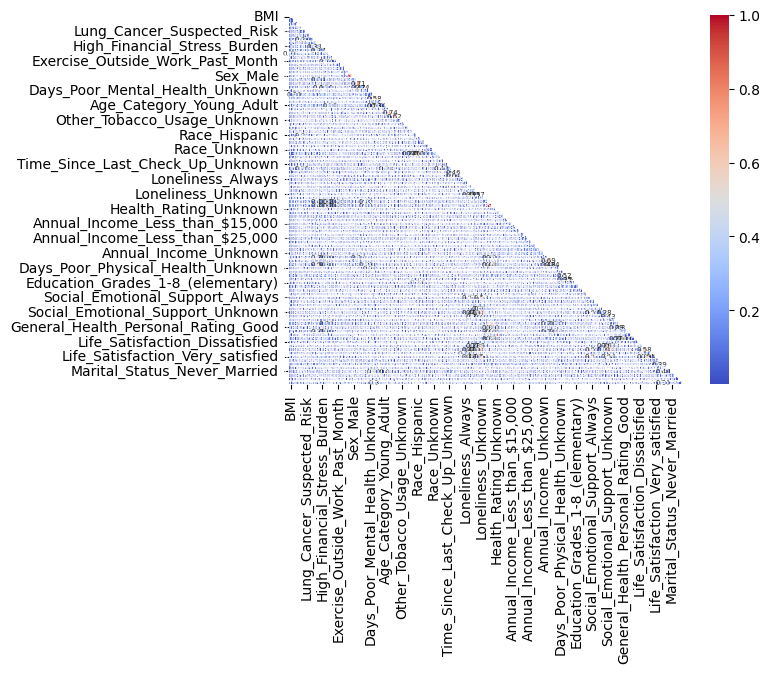

In [57]:
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', annot_kws={"size": 5})
plt.show() # Results are incredibly small due to the one-hot encoding variables

In [53]:
corr_matrix_a = x_train_imputed.corr().abs() 

threshold = 0.4

upper = corr_matrix.where(np.triu(np.ones(corr_matrix_a.shape), k=1).astype(bool))

strong_pairs = [(col1, col2, upper.loc[col1, col2])
                for col1 in upper.columns
                for col2 in upper.index
                if pd.notnull(upper.loc[col1, col2]) and upper.loc[col1, col2] >= threshold]

for pair in strong_pairs:
    print(pair)

('Number_of_Days_Last_Month_Poor_Health', 'Days_Poor_Mental_Health_14+_Days', 0.4041048789237312)
('Number_of_Days_Last_Month_Poor_Health', 'Health_Rating_Fair_or_Poor_Health', 0.4055005901185241)
('Number_of_Days_Last_Month_Poor_Health', 'Health_Rating_Good_or_Better_Health', 0.40585939682273275)
('Number_of_Days_Last_Month_Poor_Health', 'Days_Poor_Physical_Health_14+_Days', 0.535057206969638)
('Sex_Female', 'Sex_Male', 1.0000000000000002)
('Days_Poor_Mental_Health_0_Days', 'Days_Poor_Mental_Health_1-13_Days', 0.7058640369061505)
('Days_Poor_Mental_Health_0_Days', 'Days_Poor_Mental_Health_14+_Days', 0.4745681082385561)
('Age_Category_Elderly', 'Age_Category_Middle_Aged', 0.5824077739215179)
('Age_Category_Elderly', 'Age_Category_Young_Adult', 0.5270972749847302)
('Age_Category_Young_Adult', 'Marital_Status_Never_Married', 0.41510790645829265)
('Other_Tobacco_Usage_Every Day', 'Other_Tobacco_Usage_Not at all', 0.7371182930722004)
('Other_Tobacco_Usage_Not at all', 'Other_Tobacco_Usage_

## Export pre-processed data as CSV files to be used in models

In [54]:
# Written by Elizabeth Greenan
# Source: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html
# NOTE: These files are too big to be put on GitHub, but this code outputs them in the data folder of the Repository
# so they can be used in future scripts

In [55]:
x_train_scaled.to_csv("../data/x_train.csv", index = False)
x_test_scaled.to_csv("../data/x_test.csv", index = False)

In [56]:
y_train.to_csv("../data/y_train.csv", index = False)
y_test.to_csv("../data/y_test.csv", index = False)